# 05. 세션 간 구매 여정 EDA

## 분석 개요

- 목적: 04의 동일 세션 퍼널에서 확인되지 않은 동일 상품의 선행 view·cart가 이전 세션에서 관찰되는지 진단한다.
- 문제 정의: cart가 있는 session-product 중 같은 세션의 선행 view가 확인된 비율은 19.14%였고, 04는 나머지 경로의 세션 간 연결을 확인하지 않았다.
- 데이터 소스: 예비 진단은 검증된 mart_session·mart_session_product만 소비하며 raw(events)는 조회하지 않는다.
- 분석 단위: §1은 사용자·상품(user-product), §2는 세션, §3-§4는 cart 또는 purchase가 관찰된 session-product다.
- 선행 세션 기준: 같은 user_id·product_id에서 이전 session_end가 현재 session_start보다 빠른 비중첩 세션만 선행 세션으로 인정한다.
- 범위: 현재 마트에는 상품별 이벤트 시각과 remove가 없어 정확한 이벤트 간격·장바구니 상태는 판정하지 않는다. 이 노트북의 예비 진단으로 새 여정 마트의 필요 범위를 확정한다.
- 해석: 이전 세션 행동의 관찰은 경로 복원 가능성을 뜻할 뿐, 구매 원인이나 장바구니 유지 상태를 입증하지 않는다.

In [1]:
import os
import re
import time
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)

color_map = {
    'view': '#3B82F6',
    'cart': '#F59E0B',
    'purchase': '#10B981',
    'remove': '#EF4444',
    'neutral': '#94A3B8',
}

In [2]:
def find_sql(name):
    for base in (Path.cwd(), Path.cwd().parent):
        cand = base / 'sql' / name
        if cand.exists():
            return cand
    raise FileNotFoundError(f'sql/{name} 없음 (cwd={Path.cwd()})')

SQL_FILE = find_sql('05_purchase_journey_eda.sql')
CACHE_DIR = SQL_FILE.parent.parent / 'cache'

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, refresh=False, **kwargs):
    cache_path = CACHE_DIR / f'{name}.parquet'
    if cache_path.exists() and not refresh:
        try:
            df = pd.read_parquet(cache_path)
            print(f"[{name}] 캐시 로드 · {len(df):,}행")
            return df
        except Exception:
            pass
    t0 = time.time()
    df = pd.read_sql(text(Q[name]), engine, **kwargs)
    elapsed = time.time() - t0
    try:
        CACHE_DIR.mkdir(exist_ok=True)
        df.to_parquet(cache_path, index=False)
        note = '→ 캐시 저장'
    except Exception as e:
        note = f'(캐시 미저장: {type(e).__name__})'
    print(f"[{name}] 실행 {elapsed:.1f}s · {len(df):,}행 {note}")
    return df

---
## 1. 동일 사용자·상품의 반복 세션 규모

분석 단위는 **사용자·상품(user_id × product_id)** 이다. 동일 상품이 한 사용자에게 여러 세션에서 관찰되는 규모를 확인해 세션 간 여정 분석의 모집단이 충분한지 판단한다. `사용자상품_조합수`는 구간에 속한 user-product의 수, `세션상품_조합수`는 해당 조합들이 여러 세션에서 관찰된 횟수의 합이다. view·cart·purchase 도달 열도 이벤트 건수가 아니라 해당 행동이 한 번 이상 있었던 세션·상품 조합 수다. 현재 mart_session_product는 view·cart·purchase 중 하나 이상 있는 session-product만 포함하므로 remove-only 조합은 이 절의 범위 밖이다.

In [3]:
scope = run('jn_unit_scope')  # 사용자·상품의 관측 세션 수 분포
scope

[jn_unit_scope] 캐시 로드 · 4행


,관측세션구간,사용자상품_조합수,세션상품_조합수,view도달_세션상품수,cart도달_세션상품수,purchase도달_세션상품수
0,1세션,7962409,7962409.0,5437601.0,3179600.0,542933.0
1,2세션,1208077,2416154.0,1421066.0,917008.0,447549.0
2,3-5세션,402828,1370891.0,928689.0,461093.0,204833.0
3,6+세션,39710,352594.0,294834.0,68378.0,26432.0


In [4]:
scope_total = int(scope['사용자상품_조합수'].sum())
scope_single = int(scope.loc[scope['관측세션구간'] == '1세션', '사용자상품_조합수'].sum())
scope_multi = int(scope.loc[scope['관측세션구간'] != '1세션', '사용자상품_조합수'].sum())
scope_multi_sessions = int(
    scope.loc[scope['관측세션구간'] != '1세션', '세션상품_조합수'].sum()
)
scope_session_products = int(scope['세션상품_조합수'].sum())
purchase_total = int(scope['purchase도달_세션상품수'].sum())
purchase_multi = int(
    scope.loc[scope['관측세션구간'] != '1세션', 'purchase도달_세션상품수'].sum()
)
print(
    f"1세션 user-product {scope_single:,} / {scope_total:,} "
    f"({scope_single / scope_total * 100:.2f}%)"
)
print(
    f"2개 이상 세션 user-product {scope_multi:,} / {scope_total:,} "
    f"({scope_multi / scope_total * 100:.2f}%)"
)
print(
    f"해당 집단의 session-product {scope_multi_sessions:,} / {scope_session_products:,} "
    f"({scope_multi_sessions / scope_session_products * 100:.2f}%)"
)
print(
    f"2개 이상 세션 집단의 purchase 도달 session-product "
    f"{purchase_multi:,} / {purchase_total:,} "
    f"({purchase_multi / purchase_total * 100:.2f}%)"
)

1세션 user-product 7,962,409 / 9,613,024 (82.83%)
2개 이상 세션 user-product 1,650,615 / 9,613,024 (17.17%)
해당 집단의 session-product 4,139,639 / 12,102,048 (34.21%)
2개 이상 세션 집단의 purchase 도달 session-product 678,814 / 1,221,747 (55.56%)


> ### 섹션 결론
>
> - 사용자 한 명과 상품 하나를 묶은 조합은 총 9,613,024개다. 이 중 7,962,409개(82.83%)는 한 세션에서만 나타났고, 1,650,615개(17.17%)는 두 세션 이상에서 반복해서 관찰됐다.
> - 두 세션 이상에서 관찰된 조합은 전체 사용자·상품 조합의 17.17%지만, 여러 세션에 반복해서 나타나 전체 세션·상품 기록 12,102,048개 중 4,139,639개(34.21%)를 차지했다. 따라서 세션을 연결해서 살펴볼 데이터 규모는 충분하다.
> - 구매가 있었던 세션·상품 기록 1,221,747개 중 678,814개(55.56%)가 두 세션 이상 반복 관찰된 사용자·상품 집단에 포함됐다. 반복 관찰이 구매를 발생시켰다는 뜻은 아니며, 구매 전과 후 중 언제 반복 방문했는지는 뒤의 여정 분석에서 구분한다.

---
## 2. 같은 사용자의 세션 시작 시각·시간 겹침 확인

분석 단위는 **세션**이다. 같은 사용자의 세션들이 시간순으로 명확하게 이어지는지 확인한다. 두 세션이 같은 시각에 시작했거나 이전 세션이 끝나기 전에 현재 세션이 시작했다면, session_start만으로 어느 세션의 행동이 먼저였는지 판단하기 어렵다.

In [5]:
order_q = run('jn_session_order_quality')  # 같은 사용자 세션의 동일 시작·시간 겹침 확인
oq = order_q.iloc[0]
order_quality = pd.DataFrame({
    '구분': [
        '같은 시각에 시작',
        '이전 세션이 끝나기 전에 시작',
        '둘 중 하나 이상(순서 판별 주의)',
    ],
    '세션수': [
        int(oq['같은시각시작_주의세션수']),
        int(oq['이전세션과_시간겹침_세션수']),
        int(oq['순서판별_주의세션수']),
    ],
})
order_quality['전체세션대비_비율_pct'] = (
    order_quality['세션수'] / int(oq['전체세션수']) * 100
)
order_quality.round(4)

[jn_session_order_quality] 캐시 로드 · 1행


,구분,세션수,전체세션대비_비율_pct
0,같은 시각에 시작,52554,1.1680
1,이전 세션이 끝나기 전에 시작,494710,10.9948
2,둘 중 하나 이상(순서 판별 주의),511803,11.3747


> ### 섹션 결론
>
> - 전체 4,499,479세션 중 같은 사용자의 다른 세션과 같은 시각에 시작한 세션은 52,554개(1.168%)다. 이전 세션이 끝나기 전에 시작한 세션은 494,710개(10.995%)다.
> - 두 문제 중 하나라도 있는 세션은 중복을 제외하면 511,803개(11.375%)다. 이 세션들은 시작 시각만 보고 어느 세션이 먼저인지 정하면 행동 순서를 잘못 연결할 수 있다.
> - 따라서 현재 예비 분석에서는 이전 세션이 완전히 끝난 후 시작한 세션만 연결한다. 겹치는 세션의 정확한 상품 행동 순서는 새 여정 마트에 저장할 실제 이벤트 시각으로 다시 확인한다.

---
## 3. cart·purchase 전에 동일 상품 행동이 있었는지 확인

분석 단위는 **cart 또는 purchase가 있는 세션·상품 조합**이다. 먼저 같은 세션 안에서 선행 view 또는 완전한 view → cart → purchase 순서가 확인되는지 본다. 완전한 3단계 경로가 확인되지 않아도 실패로 보지 않고, 같은 사용자·상품의 이전 세션 중 현재 세션이 시작되기 전에 완전히 끝난 세션에 view·cart가 있었는지 각각 찾는다.

- cart 기준: 같은 세션에서 view 후 cart가 있었는지 확인하고, 없으면 완전히 끝난 이전 세션의 view를 찾는다.
- purchase 기준: 같은 세션에서 view → cart → purchase가 확인되는지 보고, 없으면 완전히 끝난 이전 세션의 view·cart·view → cart를 각각 찾는다.
- SQL의 `이전_view세션_최근종료시각`은 현재 세션보다 앞에 놓인 view 세션들의 종료시각 중 가장 최근 값을 뜻한다. 이 값이 현재 세션 시작보다 빠를 때만 이전 세션의 view로 인정한다. cart와 view → cart 이력도 같은 방식으로 판정한다.

이 단계는 이전 행동이 관찰됐는지만 확인하는 예비 진단이다. 이전 view와 cart가 하나의 연속된 구매 여정인지, 장바구니 상태가 다음 세션까지 유지됐는지는 아직 판정하지 않는다.

In [6]:
coverage = run('jn_prior_coverage')  # cart·purchase 전에 동일 상품 행동이 있었는지 확인
cv = coverage.iloc[0]
coverage_table = pd.DataFrame({
    '기준행동': ['cart'] * 5 + ['purchase'] * 6,
    '확인내용': [
        'cart가 있는 전체 세션·상품',
        '같은 세션에서 view 후 cart 확인',
        '같은 세션에서 선행 view 미확인',
        '선행 view 미확인 중 이전에 끝난 세션의 view 확인',
        '현재·이전 세션 모두 선행 view 미확인',
        'purchase가 있는 전체 세션·상품',
        '같은 세션에서 view→cart→purchase 확인',
        '같은 세션에서 완전한 순서 미확인',
        '완전한 순서 미확인 중 이전에 끝난 세션의 view 확인',
        '완전한 순서 미확인 중 이전에 끝난 세션의 cart 확인',
        '완전한 순서 미확인 중 이전에 끝난 세션의 view→cart 확인',
    ],
    '세션상품수': [
        int(cv['cart가_있는_세션상품수']),
        int(cv['같은세션에서_view후_cart확인수']),
        int(cv['같은세션에서_선행view없는_cart수']),
        int(cv['이전에끝난세션_view확인_cart수']),
        int(cv['현재와이전세션_선행view미확인_cart수']),
        int(cv['purchase가_있는_세션상품수']),
        int(cv['같은세션에서_view_cart_purchase순차확인수']),
        int(cv['같은세션에서_완전순차미확인_purchase수']),
        int(cv['이전에끝난세션_view확인_purchase수']),
        int(cv['이전에끝난세션_cart확인_purchase수']),
        int(cv['이전에끝난세션_view_cart순차확인_purchase수']),
    ],
})
coverage_table

[jn_prior_coverage] 캐시 로드 · 1행


,기준행동,확인내용,세션상품수
0,cart,cart가 있는 전체 세션·상품,4626079
1,cart,같은 세션에서 view 후 cart 확인,885651
2,cart,같은 세션에서 선행 view 미확인,3740428
3,cart,선행 view 미확인 중 이전에 끝난 세션의 view 확인,144095
4,cart,현재·이전 세션 모두 선행 view 미확인,3596333
5,purchase,purchase가 있는 전체 세션·상품,1221747
6,purchase,같은 세션에서 view→cart→purchase 확인,132235
7,purchase,같은 세션에서 완전한 순서 미확인,1089512
8,purchase,완전한 순서 미확인 중 이전에 끝난 세션의 view 확인,240250
9,purchase,완전한 순서 미확인 중 이전에 끝난 세션의 cart 확인,556137


In [7]:
cart_missing = int(cv['같은세션에서_선행view없는_cart수'])
cart_recovered = int(cv['이전에끝난세션_view확인_cart수'])
purchase_missing = int(cv['같은세션에서_완전순차미확인_purchase수'])
purchase_prior_cart = int(cv['이전에끝난세션_cart확인_purchase수'])
purchase_prior_ordered_cart = int(
    cv['이전에끝난세션_view_cart순차확인_purchase수']
)
print(
    f"같은 세션에서 선행 view가 없는 cart 중 이전에 끝난 세션의 view 확인 "
    f"{cart_recovered:,} / {cart_missing:,} ({cart_recovered / cart_missing * 100:.2f}%)"
)
print(
    f"같은 세션에서 완전한 순서가 없는 purchase 중 이전에 끝난 세션의 cart 확인 "
    f"{purchase_prior_cart:,} / {purchase_missing:,} "
    f"({purchase_prior_cart / purchase_missing * 100:.2f}%)"
)
print(
    f"같은 세션에서 완전한 순서가 없는 purchase 중 이전에 끝난 세션의 view→cart 확인 "
    f"{purchase_prior_ordered_cart:,} / {purchase_missing:,} "
    f"({purchase_prior_ordered_cart / purchase_missing * 100:.2f}%)"
)

같은 세션에서 선행 view가 없는 cart 중 이전에 끝난 세션의 view 확인 144,095 / 3,740,428 (3.85%)
같은 세션에서 완전한 순서가 없는 purchase 중 이전에 끝난 세션의 cart 확인 556,137 / 1,089,512 (51.04%)
같은 세션에서 완전한 순서가 없는 purchase 중 이전에 끝난 세션의 view→cart 확인 138,796 / 1,089,512 (12.74%)


**cart 기준 포함 관계**  
분석 단위는 cart가 있는 세션·상품 조합이다.

```text
cart가 있는 전체 세션·상품 4,626,079
│
├─ 같은 세션에서 view → cart 확인        885,651
│
└─ 같은 세션에서 선행 view 미확인      3,740,428
   └─ 이 3,740,428건을 대상으로 이전 세션 view를 보수 기준으로 확인
      ├─ 이전에 끝난 세션에서 view 확인      144,095 (3.85%)
      └─ 이전 세션에서도 view 미확인       3,596,333 (96.15%)
```

첫 번째로 전체 cart 세션·상품을 현재 세션의 view → cart 확인 여부에 따라 나눈다. 두 번째로 현재 세션에서 선행 view가 확인되지 않은 집단만 이전 세션의 동일 상품 view 확인 여부에 따라 다시 나눈다.

**purchase 기준 포함 관계**  
분석 단위는 purchase가 있는 세션·상품 조합이다.

```text
purchase가 있는 전체 세션·상품 1,221,747
│
├─ 같은 세션에서 view → cart → purchase 확인       132,235
│
└─ 같은 세션에서 완전한 순서 미확인              1,089,512
   └─ 이 1,089,512건을 대상으로 이전 세션 이력을 각각 확인
      ├─ 이전에 끝난 세션에서 view 확인          240,250 (22.05%)
      ├─ 이전에 끝난 세션에서 cart 확인          556,137 (51.04%)
      └─ 이전에 끝난 세션에서 view → cart 확인   138,796 (12.74%)
         ※ 세 조건은 중복 가능하며 합계 대상이 아님
```

전체 purchase 세션·상품은 현재 세션의 완전한 3단계 순서 확인 여부에 따라 두 집단으로 나뉜다. 그 아래 세 값은 완전한 순서가 확인되지 않은 동일한 1,089,512건에서 이전 view·cart·view → cart를 각각 따로 확인한 결과다. 한 세션·상품이 여러 항목에 동시에 포함될 수 있으므로 세 값을 더하거나 나머지 집단으로 해석하지 않는다.

05의 예비 집계에서 `완전한 3단계 순서 미확인`은 구매 경로가 잘못됐다는 뜻이 아니다. 논리적인 strict view → purchase의 포함관계는 아래와 같으며, 05 마트만으로는 구매 에피소드 안의 정확한 중간 cart 여부를 배타적으로 판정하지 않는다.

```text
strict view → purchase
│
├─ 중간 cart 확인: strict view → cart → purchase
└─ 중간 cart 미확인: strict view → purchase
```

중간 cart 미확인은 cart 이벤트가 데이터 전체에 없다는 뜻이 아니라, 해당 구매 에피소드의 view와 purchase 사이에서 유효한 cart가 확인되지 않았다는 뜻이다. 이 구분은 실제 이벤트 시각과 이전 purchase 경계를 함께 쓰는 06에서 수행한다.

### 세션 겹침을 포함했을 때 이전 view 확인 범위

같은 세션에서 선행 view가 확인되지 않은 cart를 대상으로 이전 세션의 동일 상품 view를 두 기준으로 확인한다.

- 보수 기준: 앞에 놓인 view 세션 중 가장 늦게 끝난 세션도 현재 세션 시작 전에 종료된 경우만 인정한다.
- 느슨한 기준: view 세션이 현재 세션보다 먼저 시작했으면 인정한다. 시간이 겹치면 실제 view와 cart의 순서가 반대일 수 있으므로 가능 범위로만 사용한다.

월별 결과는 관측 시작 구간에서 이전 행동을 충분히 볼 수 없는 좌측 절단 신호가 크게 나타나는지도 함께 확인하기 위한 진단이다. 월별 차이를 좌측 절단의 영향으로 단정하지 않는다.

In [8]:
prior_sensitivity = run('jn_prior_sensitivity')  # 세션 겹침 포함 여부에 따른 이전 view 확인 범위
prior_sensitivity['보수기준_확인율_pct'] = (
    prior_sensitivity['보수기준_이전view확인수']
    / prior_sensitivity['선행view미확인_cart수'] * 100
)
prior_sensitivity['느슨기준_확인율_pct'] = (
    prior_sensitivity['느슨기준_이전view확인수']
    / prior_sensitivity['선행view미확인_cart수'] * 100
)
prior_sensitivity['기준차이_pct'] = (
    prior_sensitivity['느슨기준_확인율_pct']
    - prior_sensitivity['보수기준_확인율_pct']
)
sensitivity_total = prior_sensitivity.loc[prior_sensitivity['기준월'] == '전체'].iloc[0]
assert int(sensitivity_total['선행view미확인_cart수']) == cart_missing
assert int(sensitivity_total['보수기준_이전view확인수']) == cart_recovered
conservative_count = int(sensitivity_total['보수기준_이전view확인수'])
loose_count = int(sensitivity_total['느슨기준_이전view확인수'])
sensitivity_gap_count = loose_count - conservative_count
print(
    f"전체 보수 기준 {conservative_count:,}개 "
    f"({sensitivity_total['보수기준_확인율_pct']:.2f}%)"
)
print(
    f"전체 느슨한 기준 {loose_count:,}개 "
    f"({sensitivity_total['느슨기준_확인율_pct']:.2f}%)"
)
print(
    f"기준 차이 {sensitivity_gap_count:,}개 "
    f"({sensitivity_total['기준차이_pct']:.2f}%p)"
)
prior_sensitivity.round({
    '보수기준_확인율_pct': 2,
    '느슨기준_확인율_pct': 2,
    '기준차이_pct': 2,
})

[jn_prior_sensitivity] 캐시 로드 · 6행
전체 보수 기준 144,095개 (3.85%)
전체 느슨한 기준 147,142개 (3.93%)
기준 차이 3,047개 (0.08%p)


,기준월,선행view미확인_cart수,보수기준_이전view확인수,느슨기준_이전view확인수,보수기준_확인율_pct,느슨기준_확인율_pct,기준차이_pct
0,2019-10,719043,17719.0,18326.0,2.46,2.55,0.08
1,2019-11,877110,32729.0,33447.0,3.73,3.81,0.08
2,2019-12,615766,26435.0,26950.0,4.29,4.38,0.08
3,2020-01,751897,32843.0,33434.0,4.37,4.45,0.08
4,2020-02,776612,34369.0,34985.0,4.43,4.50,0.08
5,전체,3740428,144095.0,147142.0,3.85,3.93,0.08


> ### 섹션 결론
>
> - 같은 세션에서 선행 view가 확인되지 않은 cart 3,740,428개 중 이전 동일 상품 view가 확인된 경우는 보수 기준 144,095개(3.85%), 겹치는 세션까지 허용한 느슨한 기준 147,142개(3.93%)다. 차이는 3,047개·0.08%p로 작아, 세션 겹침을 포함해도 이전 view 확인 비율이 낮다는 관찰은 유지된다. 두 값은 실제 이벤트 시각으로 확정한 비율이 아니라 확인 가능한 범위다.
> - 보수 기준의 월별 확인율은 2019-10 2.46%에서 2020-02 4.43%로 높아졌다. 관측 시작 직후에는 그 이전 view를 볼 수 없는 좌측 절단과 함께 월별 사용자·상품 구성 및 데이터 품질 차이가 섞일 수 있으므로 어느 하나를 원인으로 단정하지 않는다.
> - 같은 세션에서 완전한 view → cart → purchase가 확인되지 않은 purchase는 1,089,512개다. 이전에 끝난 세션에서 동일 상품 cart가 확인된 경우는 556,137개(51.04%)지만, 이전 cart 세션에서 이미 purchase가 발생한 반복 구매 가능 경로도 포함된다. 따라서 51.04%를 지연 구매율이나 장바구니 이월 비율로 해석하지 않는다.
> - 이전에 끝난 세션에서 동일 상품의 view → cart까지 확인된 purchase는 138,796개(12.74%)다. 이전 view·cart·view → cart 확인값은 서로 겹칠 수 있으며, 배타적인 여정 유형은 상품별 실제 이벤트 시각을 저장한 새 마트에서 구분한다.

---
## 4. 이전 행동 세션과 현재 행동 세션 사이의 시간

분석 단위는 **이전 세션에서 동일 상품 행동이 확인된 현재 세션·상품 조합**이다. 다음 두 집단이 대상이다.

- 현재 세션에서 선행 view가 확인되지 않은 cart 중, 이전에 끝난 세션에서 동일 상품 view가 확인된 144,095개
- 현재 세션에서 완전한 view → cart → purchase가 확인되지 않은 purchase 중, 이전에 끝난 세션에서 동일 상품 view → cart가 확인된 138,796개

현재 마트에는 상품별 이벤트의 정확한 시각이 없다. 따라서 실제 view부터 cart까지 걸린 시간이 아니라 **이전 행동 세션이 끝난 시각부터 현재 행동 세션이 시작된 시각까지의 빈 시간**을 계산한다.

```text
이전 세션: 09:05 view ---------------- 10:00 세션 종료
                                            ↓ 쿼리가 계산하는 6시간
현재 세션:                         16:00 세션 시작 ---- 16:10 cart

실제 view → cart 시간은 7시간 5분이지만, 현재 계산값은 두 세션 사이의 빈 시간인 6시간이다.
```

따라서 아래 분포는 사용자가 행동 사이에 실제로 얼마나 고민했는지를 확정하는 값이 아니다. 새 여정 마트에서 실제 이벤트 시각으로 다시 계산하기 전에, 1일·7일·30일처럼 어떤 관측 기간을 비교할지 정하기 위한 예비 결과다.

In [9]:
journey_gap = run('jn_prior_gap')  # 이전 행동 세션과 현재 행동 세션 사이의 시간
period_order = ['24시간 미만', '1-3일', '4-7일', '8-14일', '15-30일', '31일 이상']
journey_gap['기간구간'] = pd.Categorical(journey_gap['기간구간'], period_order, ordered=True)
journey_gap = journey_gap.sort_values(['행동연결', '기간구간']).reset_index(drop=True)
journey_gap['구간비율_pct'] = journey_gap.groupby('행동연결', observed=True)['세션상품_조합수'].transform(
    lambda s: s / s.sum() * 100
)
journey_gap['누적비율_pct'] = journey_gap.groupby('행동연결', observed=True)['세션상품_조합수'].transform(
    lambda s: s.cumsum() / s.sum() * 100
)
journey_gap.round({'평균간격_시간': 1, '구간비율_pct': 2, '누적비율_pct': 2})

[jn_prior_gap] 캐시 로드 · 12행


,행동연결,기간구간,세션상품_조합수,최소간격_시간,최대간격_시간,평균간격_시간,구간비율_pct,누적비율_pct
0,이전 view → 현재 cart,24시간 미만,45535,0,23,5.8,31.60,31.60
1,이전 view → 현재 cart,1-3일,23024,24,95,54.5,15.98,47.58
2,이전 view → 현재 cart,4-7일,15299,96,191,141.0,10.62,58.20
3,이전 view → 현재 cart,8-14일,15195,192,359,269.9,10.55,68.74
4,이전 view → 현재 cart,15-30일,17774,360,743,528.3,12.33,81.08
5,이전 view → 현재 cart,31일 이상,27268,744,3607,1498.7,18.92,100.00
6,이전 view→cart → 현재 purchase,24시간 미만,80201,0,23,5.0,57.78,57.78
7,이전 view→cart → 현재 purchase,1-3일,25176,24,95,51.8,18.14,75.92
8,이전 view→cart → 현재 purchase,4-7일,11269,96,191,138.4,8.12,84.04
9,이전 view→cart → 현재 purchase,8-14일,8318,192,359,266.4,5.99,90.03


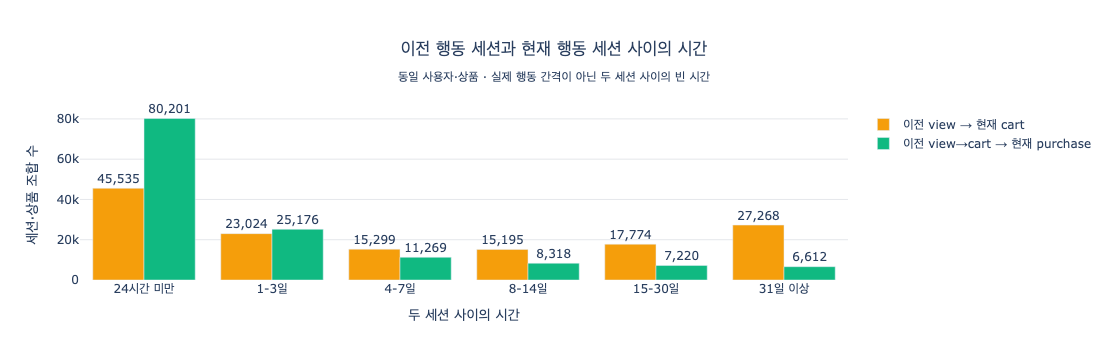

In [10]:
journey_paths = journey_gap['행동연결'].drop_duplicates().tolist()
fig = go.Figure()
for path, color in zip(journey_paths, [color_map['cart'], color_map['purchase']]):
    part = journey_gap[journey_gap['행동연결'] == path]
    fig.add_bar(
        name=path,
        x=part['기간구간'],
        y=part['세션상품_조합수'],
        marker_color=color,
        text=part['세션상품_조합수'],
        texttemplate='%{text:,.0f}',
        textposition='outside',
        cliponaxis=False,
    )
fig.update_layout(
    title=dict(
        text='이전 행동 세션과 현재 행동 세션 사이의 시간<br>'
             '<sub>동일 사용자·상품 · 실제 행동 간격이 아닌 두 세션 사이의 빈 시간</sub>',
        x=0.5,
        xanchor='center',
    ),
    barmode='group',
    plot_bgcolor='white',
    yaxis=dict(title='세션·상품 조합 수', gridcolor='#E5E7EB'),
    xaxis=dict(title='두 세션 사이의 시간'),
    margin=dict(t=110),
)
fig.show()

> ### 섹션 결론
>
> - 이전 세션의 동일 상품 view와 현재 세션의 cart가 연결된 144,095개 중 두 세션 사이가 24시간 미만인 경우는 45,535개(31.60%)다. 4-7일 구간까지 58.20%, 15-30일 구간까지 81.08%가 누적됐지만 31일 이상도 27,268개(18.92%)여서 짧은 기간에만 모이지 않았다.
> - 이전 세션에서 동일 상품 view → cart가 확인되고 현재 세션에서 purchase가 발생한 138,796개 중 두 세션 사이가 24시간 미만인 경우는 80,201개(57.78%)다. 4-7일 구간까지 84.04%, 15-30일 구간까지 95.24%가 누적돼 첫 번째 경로보다 짧은 구간에 더 많이 분포했다.
> - 이 값은 실제 view·cart·purchase 사이의 시간이 아니라 이전 세션 종료부터 현재 세션 시작까지의 빈 시간이다. 따라서 대표 구매 고민 기간으로 해석하지 않고, 새 마트에서 실제 이벤트 시각을 사용해 1일·7일·30일·전체 기간 결과를 다시 비교한다.

---
## 5. 예비 진단 결론과 다음 단계

### 핵심 발견

- user-product의 17.17%가 2개 이상 세션에 나타났고, 이들이 전체 session-product의 34.21%를 차지해 세션 간 분석 모집단이 확인됐다.
- 같은 세션에서 선행 view가 없는 cart 중 이전 동일 상품 view 확인 비율은 보수 기준 3.85%, 겹치는 세션을 허용한 느슨한 기준 3.93%였다. 차이는 0.08%p로 작아 세션 겹침을 포함해도 이전 view 확인 비율이 낮다는 관찰은 유지됐다.
- 같은 세션에서 완전한 경로가 없는 purchase의 51.04%에서는 이전에 끝난 세션의 동일 상품 cart가 관찰됐다. 다만 이전 cart 세션에서 이미 구매한 반복 구매 가능 경로도 포함되므로 지연 구매율로 해석하지 않고, 06에서 두 유형을 분리한다.
- 이전 세션에서 view → cart가 확인된 purchase는 12.74%였으며, 이 경로는 4-7일 구간까지 84.04%, 15-30일 구간까지 95.24%가 누적됐다. 현재 마트로는 이전 cart 존재와 완전 순차 경로를 구분할 수 있지만 세션 내 상품 이벤트의 정확한 시각은 복원할 수 없다.

### 정의 · 한계

- 보수 기준은 이전 view 세션이 현재 세션보다 먼저 완전히 끝난 경우만 연결한다. 전체 세션의 11.375%에는 같은 시각 시작이나 시간 겹침이 있었지만, 이를 허용한 느슨한 기준과 보수 기준의 이전 view 확인율 차이는 0.08%p였다. 상품별 실제 행동 순서는 06에서 이벤트 시각으로 다시 판정한다.
- 보수 기준의 이전 view 확인율은 2019-10 2.46%에서 2020-02 4.43%로 달랐다. 관측 시작 이전 행동을 볼 수 없는 좌측 절단과 월별 구성·품질 차이가 함께 섞일 수 있으므로 월 차이의 원인은 확정하지 않는다.
- 이전 cart가 관찰됐다는 사실은 해당 장바구니가 현재 purchase까지 유지됐거나 구매를 발생시켰다는 의미가 아니다. 이전 cart 세션의 purchase 동반 여부와 현재 purchase 전 중간 구매를 확인해야 지연 구매 후보와 반복 구매 후보를 나눌 수 있다.

### 다음 단계

- 02에 `mart_user_product_session`을 추가한다. 분석 단위는 user_id × product_id × user_session이며 view·cart·remove·purchase별 건수와 첫·마지막 event_time을 보존한다. remove-only 조합도 포함한다.
- 기본키는 user_session × product_id, 여정 탐색 인덱스는 user_id × product_id × session_start로 둔다. raw(events)는 마트 생성·독립 검증에서만 사용하고 06 분석 집계는 새 마트만 소비한다.
- 구매 세션·상품을 기준점으로 가장 가까운 이전 view·cart를 연결한다. 구매 발생 시 이전 에피소드를 닫고, 이전 purchase 이후의 행동만 현재 구매 후보로 사용한다. 관측 첫 구매·반복 구매는 구매 차수 축, 같은 세션 완결·이전 세션 cart 연결은 경로 축으로 따로 판정한 뒤 결합한다.
- 04의 세션 내 strict 3단계 완주율 2.30%와 사용자·상품 기준 1일·7일·30일 구매 도달률을 나란히 제시한다. 두 값은 경로·단위·시간 창이 다른 별도 지표이며, 04의 값을 수정한 전환율로 표현하지 않는다.
- 04의 개선 우선순위 1위 category_id `1487580006300255120`만 표적 검증한다. 같은 세션 전환이 낮은 상태가 사용자·상품 N일 구매 도달에서도 유지되는지 확인하고 카테고리 전체 순위 분석은 반복하지 않는다.
- N일 지표는 행동 이후 N일을 끝까지 관측할 수 있는 경우만 분모에 포함한다. 과거 N일 행동을 찾는 분석은 관측 시작 후 N일이 지난 구매만 완전 관측 분모에 포함하고, 전체 과거 결과는 월별 민감도를 함께 제시한다.
- remove-only 경로와 1세션·2개 이상 세션 사용자 차이는 보조 분석으로 제한한다. remove 이전의 가장 가까운 동일 상품 행동을 확인하되 장바구니 유지와 로깅 누락을 모두 가능한 설명으로 남긴다. 최종 결과는 핵심 경로 하나의 개선 후보와 A/B 테스트 설계로 마무리한다.